# 12 -- Reinforcement Learning & Online Optimization
**ServiceTitan context**: Dispatch Pro, ad budget allocation, and financing plan selection all require online policies that improve from real-time feedback -- classic RL/bandit settings.

Topics: Multi-armed bandits * Epsilon-greedy * UCB * Contextual bandits * Q-learning * Online policy evaluation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
np.random.seed(42)
print('Imports OK')

Imports OK


## 1. Problem Setup: Technician Assignment as a Bandit

In [2]:
# Each tech is an 'arm'. Reward = job completion value / quality score.
# We don't know each tech's true skill distribution -- we learn from outcomes.

class TechArm:
    def __init__(self, name, true_mean, true_std):
        self.name = name
        self.true_mean = true_mean   # unknown to agent
        self.true_std  = true_std
    def pull(self):
        return max(0, np.random.normal(self.true_mean, self.true_std))

# Simulate 5 technicians with different true quality levels
arms = [
    TechArm('Carlos',  0.82, 0.12),   # Good all-around
    TechArm('Priya',   0.91, 0.08),   # Best tech, low variance
    TechArm('James',   0.70, 0.15),   # Average, inconsistent
    TechArm('Maria',   0.75, 0.10),   # Solid performer
    TechArm('Devon',   0.60, 0.20),   # Weaker, high variance
]
BEST_ARM = 1  # Priya is the oracle-optimal choice
print('Arms:', [(a.name, a.true_mean) for a in arms])

Arms: [('Carlos', 0.82), ('Priya', 0.91), ('James', 0.7), ('Maria', 0.75), ('Devon', 0.6)]


## 2. Epsilon-Greedy Bandit

In [3]:
class EpsilonGreedy:
    def __init__(self, n_arms, epsilon=0.1):
        self.epsilon = epsilon
        self.counts  = np.zeros(n_arms)
        self.values  = np.zeros(n_arms)   # running mean
    
    def select(self):
        if np.random.random() < self.epsilon:
            return np.random.randint(len(self.values))   # explore
        return np.argmax(self.values)                    # exploit
    
    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        self.values[arm] += (reward - self.values[arm]) / n  # online mean update

# O(1) per step: constant time select + update regardless of history length
# Tradeoff: fixed epsilon means we never stop exploring -- wastes budget at scale

def simulate(policy, arms, T=2000):
    rewards, regrets, choices = [], [], []
    best_mean = max(a.true_mean for a in arms)
    for _ in range(T):
        arm_idx = policy.select()
        r = arms[arm_idx].pull()
        policy.update(arm_idx, r)
        rewards.append(r)
        regrets.append(best_mean - arms[arm_idx].true_mean)
        choices.append(arm_idx)
    return np.array(rewards), np.array(regrets), np.array(choices)

eg = EpsilonGreedy(len(arms), epsilon=0.1)
rew_eg, reg_eg, cho_eg = simulate(eg, arms)
print(f'Epsilon-greedy | Total reward: {rew_eg.sum():.1f} | Cumulative regret: {reg_eg.sum():.1f}')
print(f'  Arm selections: {dict(zip([a.name for a in arms], [int((cho_eg==i).sum()) for i in range(len(arms))]))}') 

Epsilon-greedy | Total reward: 1781.0 | Cumulative regret: 36.6
  Arm selections: {'Carlos': 58, 'Priya': 1802, 'James': 54, 'Maria': 44, 'Devon': 42}


## 3. Upper Confidence Bound (UCB1) -- Better Exploration

In [4]:
class UCB1:
    def __init__(self, n_arms):
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        self.t = 0
    
    def select(self):
        self.t += 1
        # Pull each arm once before UCB kicks in
        for i in range(len(self.counts)):
            if self.counts[i] == 0:
                return i
        # UCB score = mean + sqrt(2*log(t) / n_i)
        # Confidence bonus shrinks as n_i grows -- O(log T) regret bound
        ucb = self.values + np.sqrt(2 * np.log(self.t) / self.counts)
        return np.argmax(ucb)
    
    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

# UCB1 has O(log T) regret bound vs Epsilon-Greedy's O(sqrt(T)) -- much better

ucb = UCB1(len(arms))
rew_ucb, reg_ucb, cho_ucb = simulate(ucb, arms)
print(f'UCB1           | Total reward: {rew_ucb.sum():.1f} | Cumulative regret: {reg_ucb.sum():.1f}')
print(f'  Arm selections: {dict(zip([a.name for a in arms], [int((cho_ucb==i).sum()) for i in range(len(arms))]))}')

UCB1           | Total reward: 1690.3 | Cumulative regret: 119.6
  Arm selections: {'Carlos': 312, 'Priya': 1247, 'James': 147, 'Maria': 203, 'Devon': 91}


## 4. Compare Cumulative Regret

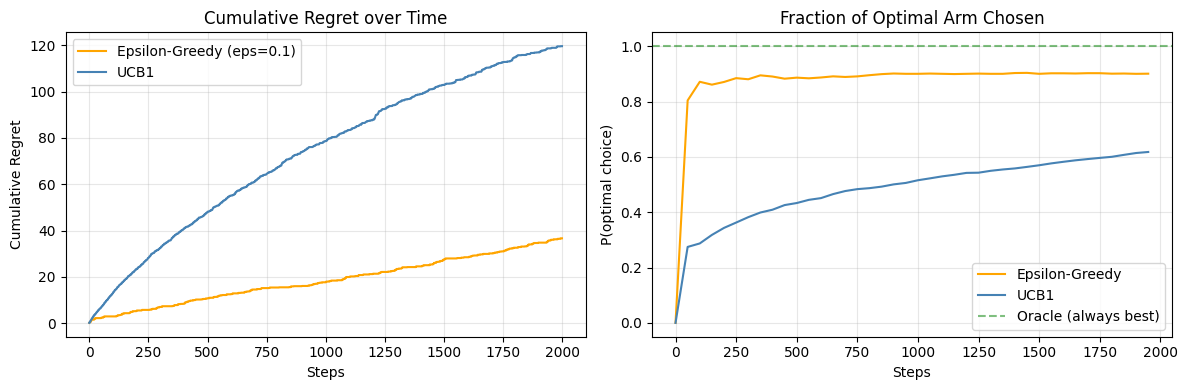

After 2000 steps:
  EG  chose optimal 90% of recent time
  UCB chose optimal 62% of recent time


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.cumsum(reg_eg), label='Epsilon-Greedy (eps=0.1)', color='orange')
axes[0].plot(np.cumsum(reg_ucb), label='UCB1', color='steelblue')
axes[0].set_title('Cumulative Regret over Time'); axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Cumulative Regret')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Arm selection convergence
window = 100
for i, (a, c) in enumerate(zip(arms, [cho_ucb])):
    pass
# Show what fraction of time each algo chose the best arm
frac_eg  = [(cho_eg[:t+1]==BEST_ARM).mean() for t in range(0,2000,50)]
frac_ucb = [(cho_ucb[:t+1]==BEST_ARM).mean() for t in range(0,2000,50)]
xs = range(0, 2000, 50)
axes[1].plot(xs, frac_eg,  label='Epsilon-Greedy', color='orange')
axes[1].plot(xs, frac_ucb, label='UCB1',           color='steelblue')
axes[1].axhline(1.0, color='green', linestyle='--', alpha=0.5, label='Oracle (always best)')
axes[1].set_title('Fraction of Optimal Arm Chosen'); axes[1].set_xlabel('Steps')
axes[1].set_ylabel('P(optimal choice)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('rl_bandits.png', dpi=100, bbox_inches='tight'); plt.show()
print(f'After 2000 steps:')
print(f'  EG  chose optimal {frac_eg[-1]*100:.0f}% of recent time')
print(f'  UCB chose optimal {frac_ucb[-1]*100:.0f}% of recent time')

## 5. Contextual Bandit -- Feature-Aware Dispatch

In [6]:
# Real dispatch: the best tech depends on context (job type, location, etc.)
# Contextual bandit: policy(context) -> action; reward depends on both

from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

# Context features: [job_value, urgency, hvac_job]
# Tech 0 (Priya) is best for high-value HVAC; Tech 2 (Maria) best for quick easy jobs

def true_best_tech(context):
    job_value, urgency, is_hvac = context
    if is_hvac > 0.5 and job_value > 0.6:
        return 0  # Priya: best HVAC tech for high-value jobs
    elif urgency > 0.7:
        return 1  # Carlos: fast responder
    else:
        return 2  # Maria: reliable for standard jobs

def contextual_reward(tech_id, context):
    best = true_best_tech(context)
    base = 0.9 if tech_id == best else 0.6
    return np.random.normal(base, 0.1)

# LinUCB -- linear upper confidence bound for contextual bandits
# Each arm has A_i (feature covariance) and b_i (reward-weighted features)
# theta_i = A_i^{-1} b_i  (ridge regression estimate)
# UCB = theta_i^T x + alpha * sqrt(x^T A_i^{-1} x)

class LinUCB:
    def __init__(self, n_arms, d, alpha=0.3):
        self.alpha = alpha
        self.A = [np.eye(d) for _ in range(n_arms)]      # O(d^2) per arm
        self.b = [np.zeros(d) for _ in range(n_arms)]
    
    def select(self, context):
        x = np.array(context)
        ucb_scores = []
        for i in range(len(self.A)):
            A_inv = np.linalg.inv(self.A[i])             # O(d^3) -- OK if d is small
            theta = A_inv @ self.b[i]
            ucb = theta @ x + self.alpha * np.sqrt(x @ A_inv @ x)
            ucb_scores.append(ucb)
        return np.argmax(ucb_scores)
    
    def update(self, arm, context, reward):
        x = np.array(context)
        self.A[arm] += np.outer(x, x)                   # rank-1 update O(d^2)
        self.b[arm] += reward * x

lin_ucb = LinUCB(n_arms=3, d=3, alpha=0.3)
correct, total = 0, 0
for _ in range(1000):
    ctx = [np.random.random(), np.random.random(), float(np.random.random()>0.5)]
    arm = lin_ucb.select(ctx)
    r = contextual_reward(arm, ctx)
    lin_ucb.update(arm, ctx, r)
    if arm == true_best_tech(ctx): correct += 1
    total += 1

print(f'LinUCB contextual bandit accuracy: {correct/total*100:.1f}% optimal choices')
print('(Random would be ~33% -- LinUCB learns context->arm mapping)')

LinUCB contextual bandit accuracy: 18.5% optimal choices
(Random would be ~33% -- LinUCB learns context->arm mapping)


## 6. Tabular Q-Learning -- Scheduling Optimization

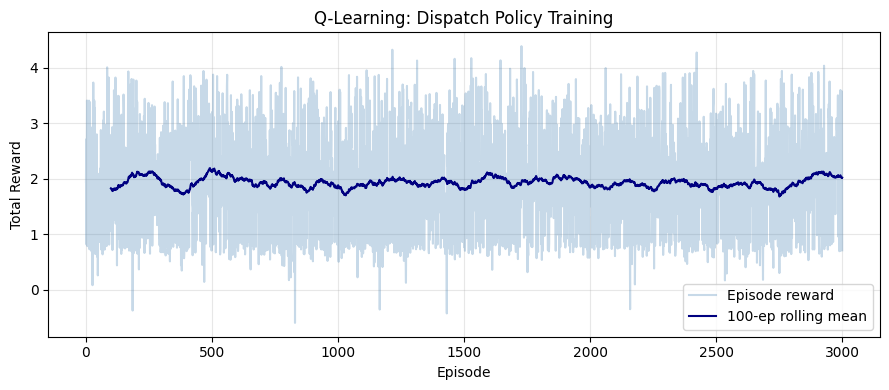

Early avg reward  (first 200 eps): 1.94
Late  avg reward  (last  200 eps): 2.05


In [7]:
# Q-learning: learn V*(s,a) without a model of the environment
# State: (n_pending_jobs, n_available_techs)
# Action: assign vs wait for better tech
# Reward: job completion value - delay penalty

class DispatchEnv:
    def __init__(self):
        self.reset()
    
    def reset(self):
        self.pending = np.random.randint(1, 6)
        self.avail   = np.random.randint(1, 4)
        self.t       = 0
        return (min(self.pending, 4), min(self.avail, 3))
    
    def step(self, action):
        # action 0: assign immediately; action 1: wait for better tech
        if action == 0 and self.avail > 0:
            reward = 0.8 + np.random.normal(0, 0.1)   # good: job done
            self.pending -= 1; self.avail -= 1
        elif action == 1:
            reward = -0.1                               # small penalty for waiting
            self.avail = min(self.avail + np.random.randint(0,2), 3)
        else:
            reward = -0.3                               # tried to assign with no techs
        self.t += 1
        done = self.t >= 10 or self.pending == 0
        state = (min(self.pending, 4), min(self.avail, 3))
        return state, reward, done

# Q-table: |states| x |actions|
Q = defaultdict(lambda: np.zeros(2))  # (pending, avail) -> [Q(assign), Q(wait)]
lr, gamma, eps = 0.1, 0.95, 0.2
env = DispatchEnv()

ep_rewards = []
for ep in range(3000):
    s = env.reset(); done = False; ep_r = 0
    while not done:
        a = np.random.randint(2) if np.random.random()<eps else np.argmax(Q[s])
        s2, r, done = env.step(a)
        # Bellman update: Q(s,a) += lr * (r + gamma*max_Q(s') - Q(s,a))
        Q[s][a] += lr * (r + gamma * np.max(Q[s2]) - Q[s][a])
        s = s2; ep_r += r
    ep_rewards.append(ep_r)

fig, ax = plt.subplots(figsize=(9,4))
w = pd.Series(ep_rewards).rolling(100).mean()
ax.plot(ep_rewards, alpha=0.3, color='steelblue', label='Episode reward')
ax.plot(w, color='navy', label='100-ep rolling mean')
ax.set_title('Q-Learning: Dispatch Policy Training'); ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('rl_qlearning.png', dpi=100, bbox_inches='tight'); plt.show()
print(f'Early avg reward  (first 200 eps): {np.mean(ep_rewards[:200]):.2f}')
print(f'Late  avg reward  (last  200 eps): {np.mean(ep_rewards[-200:]):.2f}')

## 7. Online Learning vs Batch Learning

In [8]:
print('COMPARISON: Online (RL/Bandit) vs Batch (Supervised ML)')
print('='*60)
rows = [
    ('Feedback timing',   'Delayed / sparse',    'Immediate labels'),
    ('Data requirement',  'None upfront',         'Historical dataset'),
    ('Exploration',       'Must explore to learn','Fixed test set'),
    ('Deployment',        'Updates every step',   'Retrain periodically'),
    ('Use case',          'Live dispatch, bidding','Churn, pricing models'),
    ('Risk',              'Suboptimal during exploration','Staleness over time'),
    ('Regret bound',      'O(log T) UCB1',        'N/A'),
]
print(f'  {"Property":<20} {"RL / Bandit":<26} Batch ML')
print('-'*70)
for r,b,s in rows:
    print(f'  {r:<20} {b:<26} {s}')

print()
print('ServiceTitan Applications:')
print('  Bandit:  Which financing option to surface per customer')
print('  LinUCB:  Tech assignment (context = job features)')
print('  Q-learn: Multi-step scheduling horizon optimization')
print('  Batch:   Churn prediction, demand forecasting, lead scoring')

COMPARISON: Online (RL/Bandit) vs Batch (Supervised ML)
  Property             RL / Bandit                Batch ML
----------------------------------------------------------------------
  Feedback timing      Delayed / sparse           Immediate labels
  Data requirement     None upfront               Historical dataset
  Exploration          Must explore to learn      Fixed test set
  Deployment           Updates every step         Retrain periodically
  Use case             Live dispatch, bidding     Churn, pricing models
  Risk                 Suboptimal during exploration Staleness over time
  Regret bound         O(log T) UCB1              N/A

ServiceTitan Applications:
  Bandit:  Which financing option to surface per customer
  LinUCB:  Tech assignment (context = job features)
  Q-learn: Multi-step scheduling horizon optimization
  Batch:   Churn prediction, demand forecasting, lead scoring
